In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# If CSV file is provided just use
# df = pd.read_csv(filename.csv')

data = {
    'Name': ['Alice','Bob','Charlie','Diana','Eve','Frank','Grace','Hank','Ivy','Jack',
              'Alice','Bob','Liam','Mia','Noah'],
    'Age': [20, 21, None, 19, 22, None, 20, 21, 19, None, 20, 21, 18, 23, 100],
    'Marks': [85, 90, 78, None, 88, 76, None, 95, 82, 79, 85, 90, 88, 72, 5],
    'Attendance': [90, 85, 78, 88, None, 76, 80, None, 82, 79, 90, 85, 88, 72, 95],
    'Hours_Studied': [5, 6, 4, 7, 5, None, 6, 8, 4, 5, 5, 6, 7, 3, 9]
}

df=pd.DataFrame(data)
print("Current DataSet: \n")
df

Current DataSet: 



,Name,Age,Marks,Attendance,Hours_Studied
0,Alice,20.0,85.0,90.0,5.0
1,Bob,21.0,90.0,85.0,6.0
2,Charlie,NaN,78.0,78.0,4.0
3,Diana,19.0,NaN,88.0,7.0
4,Eve,22.0,88.0,NaN,5.0
5,Frank,NaN,76.0,76.0,NaN
6,Grace,20.0,NaN,80.0,6.0
7,Hank,21.0,95.0,NaN,8.0
8,Ivy,19.0,82.0,82.0,4.0
9,Jack,NaN,79.0,79.0,5.0


In [2]:
#Task 1
print("\n Number of Null in per Column: \n")
print(df.isnull().sum())
print("\n")

print("\n Percentage of Null in per Column: \n")
print((df.isnull().sum()/len(df))*100)


 Number of Null in per Column: 

Name             0
Age              3
Marks            2
Attendance       2
Hours_Studied    1
dtype: int64



 Percentage of Null in per Column: 

Name              0.000000
Age              20.000000
Marks            13.333333
Attendance       13.333333
Hours_Studied     6.666667
dtype: float64


In [3]:
#Task2
df.fillna(df.mean(numeric_only=True), inplace=True)

df.drop_duplicates(inplace=True)

print("Nulls remaining:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Nulls remaining: 0
Shape after cleaning: (13, 5)


In [4]:
#Task3
col=df.select_dtypes(include=np.number).columns
Q1=df.quantile(0.25,numeric_only=True)
Q3=df.quantile(0.75,numeric_only=True)

IQR=Q3-Q1


outliers= df[((df[col] < (Q1-1.5*IQR)) | (df[col] > (Q3+1.5*IQR))).any(axis=1)]

print("Outliers Detected: ")
print(outliers)

Outliers Detected: 
    Name    Age  Marks  Attendance  Hours_Studied
14  Noah  100.0    5.0        95.0            9.0


In [5]:
#Task4
scaler = MinMaxScaler()
df[col]=scaler.fit_transform(df[col])
print(df)

       Name       Age     Marks  Attendance  Hours_Studied
0     Alice  0.024390  0.888889    0.782609       0.333333
1       Bob  0.036585  0.944444    0.565217       0.500000
2   Charlie  0.109756  0.811111    0.260870       0.166667
3     Diana  0.012195  0.810256    0.695652       0.666667
4       Eve  0.048780  0.922222    0.508361       0.333333
5     Frank  0.109756  0.788889    0.173913       0.452381
6     Grace  0.024390  0.810256    0.347826       0.500000
7      Hank  0.036585  1.000000    0.508361       0.833333
8       Ivy  0.012195  0.855556    0.434783       0.166667
9      Jack  0.109756  0.822222    0.304348       0.333333
12     Liam  0.000000  0.922222    0.695652       0.666667
13      Mia  0.060976  0.744444    0.000000       0.000000
14     Noah  1.000000  0.000000    1.000000       1.000000


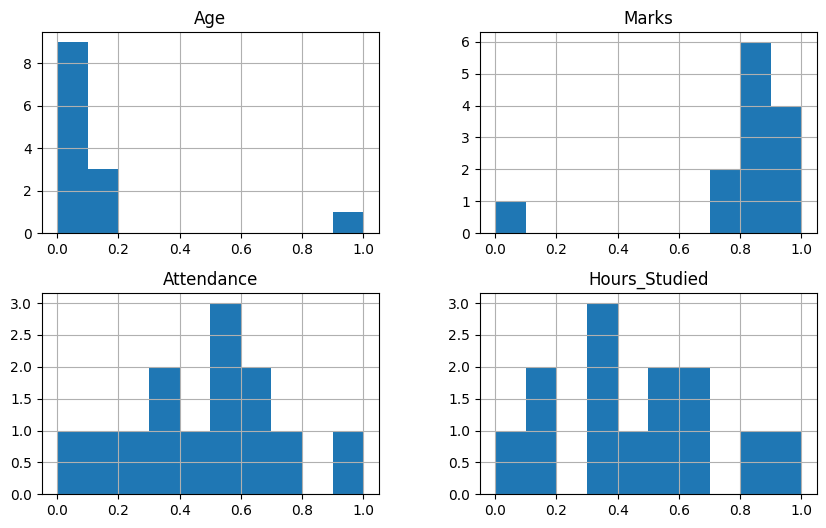

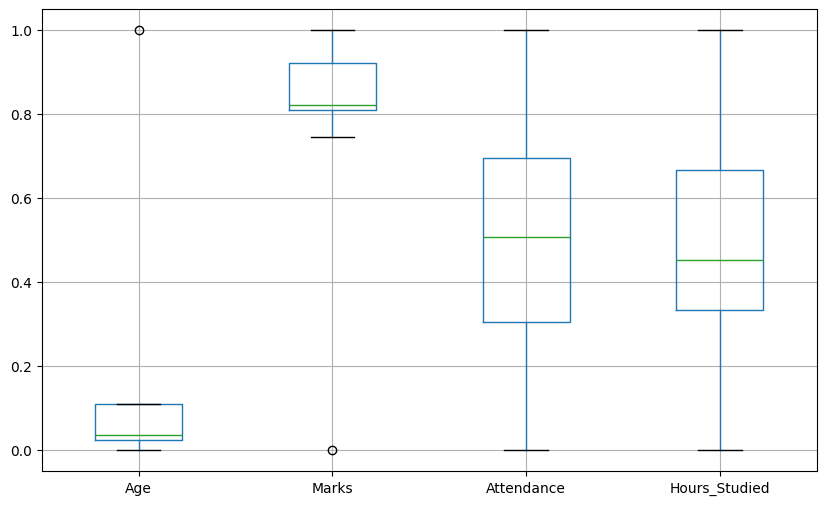

<Axes: >

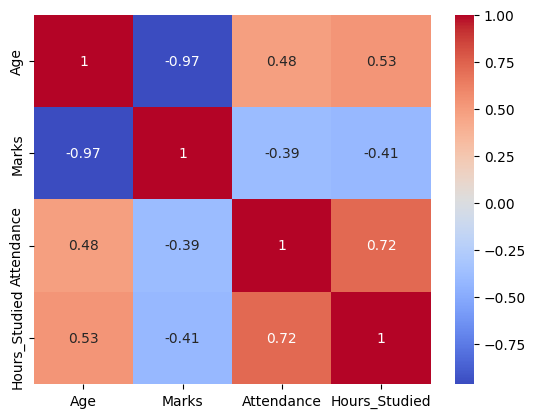

In [16]:
#Task5
df.hist(figsize=(10,6))
plt.show()

df.boxplot(figsize=(10,6))
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')